# **HEALTHCARE DATA ANALYTICS WORKFLOW - DIABETIC DATA ANALYTICS**

## Project Objective
The primary objective of this project is to perform a rigorous data preprocessing, cleaning, and Exploratory Data Analysis (EDA) on a complex healthcare dataset containing historical inpatient records of diabetic patients. By handling missing data, eliminating noise, transforming clinical features, and analyzing variable distributions, this phase aims to build a high-integrity data foundation. This structured data will allow us to uncover critical insights regarding patient demographics, hospital utilization metrics, and factors associated with clinical outcomes, such as hospital readmissions.

## Project Overview & Scope of Work 
Clinical data gathered from electronic health records (EHR) is inherently noisy, incomplete, and full of administrative placeholders. Raw medical data cannot be reliably analyzed or passed into statistical models because missing variables and bad formats distort numerical summaries.

The scope of Phase 1 focuses completely on Data Clean-up and Exploratory Data Analysis (EDA) using Python. By leveraging the Pandas and NumPy libraries, we create a reproducible preprocessing pipeline. This workflow includes removing highly vacant features, handling hidden missing values (?), removing corrupted rows, and transforming attributes into formats optimized for statistical evaluation. Once clean, we run structured univariate and bivariate statistical audits to observe initial patient trends and distributions before moving into data visualization or predictive modeling in Phase 2.

## Comprehensive Dataset Description & Structural Properties
The dataset utilized in this study represents 10 years of clinical care encounters across 130 unique hospitals and integrated healthcare facilities. It specifically tracks inpatient admissions for patients diagnosed with diabetes mellitus.

### Data Volume Summary:
- Total Patient Records (Rows): 101,766 records.

- Clinical Meaning: Each row represents an individual hospital encounter (admission) rather than a unique person. Because diabetes is a chronic condition, a single patient may appear across multiple rows via separate readmission encounters.

- Total Initial Attributes (Columns): 50 distinct clinical, demographic, and administrative features.

- Total Ingested Data Points (Cells): 5,088,300 structural cell entries.

### Feature Schema Domain Classifications:
To provide a clear taxonomy for evaluation, the 50 columns are categorized into four core operational sub-domains:

- #### Patient Identifiers (2 Columns):

  -  encounter_id: A unique system-generated tracking key assigned to each unique hospital stay.

  -  patient_nbr: A unique numerical identifier linked to the specific individual, allowing us to track recurring readmission patterns for the same         patient.

- #### Demographic Attributes (3 Columns):

  - Socio-demographic variables used to segment populations: race (ethnicity background), gender (biological sex), and age (pre-grouped into               structured    10-year intervals, e.g., [70-80)).

- #### Hospital Utilization & Severity Metrics (8 Columns):

  - Workload and complexity indicators tracking hospital resource usage. These include time_in_hospital (length of stay in days), num_lab_procedures       (the volume of diagnostic lab tests ordered), num_procedures (the count of non-lab diagnostic or surgical procedures), and num_medications (the        total number of unique generic medications prescribed).

  - It also tracks historical clinical use counters over the preceding year: number_outpatient, number_emergency, and number_inpatient visits.

- #### Clinical Diagnoses & Medication Profiles (37 Columns):

  - Medical attributes including three unique categorical ICD-9 diagnostic codes (diag_1, diag_2, diag_3), and crucial blood chemistry indicators          such     as blood glucose serum tests (max_glu_serum) and glycated hemoglobin values (A1Cresult).

  - 23 Individual Medication Columns: Features tracking specific diabetes drugs (such as metformin, glipizide, pioglitazone, and insulin). These           features capture whether the dosage during the encounter was increased (Up), decreased (Down), kept stable (Steady), or not prescribed (No).

  - Outcome & System Flags: Administrative columns tracking if a medication change occurred (change), if diabetes medication was actively prescribed       (diabetesMed), and the core target variable for our project tracking whether the patient was re-admitted to the hospital (readmitted).

## Environmental Setup & Library Importation
Before initiating the data manipulation pipeline, the foundational computational environment must be configured. We load standard, highly optimized data science libraries that provide vectorized analytical operations and structured mathematical frameworks.

**Pandas (pd)**: Leveraged for high-performance data structures (DataFrame), multi-index sorting, categorical mapping, structural slicing, and technical table manipulation.

**NumPy (np)** : Used for fundamental numerical computing, scientific arrays, and handling native IEEE 754 floating-point Not-a-Number (NaN) initializations.

In [34]:
# Import foundational libraries for data engineering and numerical operations
import pandas as pd
import numpy as np

# Adjust display options to fully audit large sets of feature columns
pd.set_option('display.max_columns', None)

## Data Loading ##

In [35]:
# Ingest the source clinical dataset into a structured Pandas DataFrame
df = pd.read_csv(r'C:\Users\siyaa\Downloads\diabetic_data.csv')

# Determine the structural scale of the uncleaned dataset
rows, columns = df.shape
print(f"Initial Dataset Scale: {rows} patient records across {columns} distinct variables.")

Initial Dataset Scale: 101766 patient records across 50 distinct variables.


## Visual Row Layout Inspection ##
To confirm data parsing alignment, structural row verification, and label integrity, we extract a visual snippet of the top five records. This provides a clear structural look at feature attributes such as age intervals, clinical identifiers, and medical classifications.



In [36]:
# Display the primary 5 records to inspect row formatting and entry behaviors
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Data Schema Integrity & Data Type Auditing ##
A critical diagnostic requirement is auditing the data types (dtypes) stored within the system memory. This step maps out continuous numerical variables (such as length of stay, procedure counts, and lab metrics) versus categorical object variables (such as medical specializations and prescription adjustments).

In [37]:
# Execute an operational data integrity audit to evaluate memory footprint and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Identification and Evaluation of Duplicated Records ##
Auditing a clinical dataset for duplicate records is a vital stage in data validation. If identical rows exist across the database, they distort statistical metrics, falsify patient counts, and heavily bias downstream analytical results.

In [38]:
# 1. Calculate and report absolute identical row duplicates in this data
total_cloned_rows = df.duplicated().sum()
print(f"Operational Data Validation: Found {total_cloned_rows} absolute duplicate rows.")

Operational Data Validation: Found 0 absolute duplicate rows.


In [39]:
# remove absolute duplicates if any exist in the future
if total_cloned_rows > 0:
    df.drop_duplicates(inplace=True)
    print("-> System Clean-up: Absolute duplicate rows successfully dropped from active workspace.")

In [40]:
# 2. Evaluate the clinical relevance of recurring unique patients vs total encounters
total_unique_individuals = df['patient_nbr'].nunique()
total_current_encounters = len(df)

print(f"Total Unique Individual Patients Evaluated : {total_unique_individuals:,}")
print(f"Total Active Hospital Encounters Verified   : {total_current_encounters:,}")
print(f"Average Recorded Admissions Per Patient     : {total_current_encounters / total_unique_individuals:.2f}")

Total Unique Individual Patients Evaluated : 71,518
Total Active Hospital Encounters Verified   : 101,766
Average Recorded Admissions Per Patient     : 1.42


## Handling Missing Values ##
In real-world clinical electronic health records (EHR), missing entries are rarely blank; they are frequently masked by administrative placeholder characters like ?. To prevent these hidden missing entries from skewing our statistical summary tables, we map and replace them with standard Python NaN indicators, then calculate the precise null percentages for each column.

In [41]:
# Convert hidden string placeholders ('?') into standardized numeric null values
df.replace('?', np.nan, inplace=True)

# Calculate the exact null value concentration for every column feature
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df)) * 100

# Consolidate results into a professional diagnostic matrix
missing_audit_matrix = pd.DataFrame({
    'Total Null Values': missing_counts,
    'Percentage (%)': missing_percentage
})

# Display features that contain missing data, sorted by severity
print("Data Quality Report - Missing Value Vector Matrix:")
print(missing_audit_matrix[missing_audit_matrix['Total Null Values'] > 0].sort_values(by='Percentage (%)', ascending=False).round(2)) 

Data Quality Report - Missing Value Vector Matrix:
                   Total Null Values  Percentage (%)
weight                         98569           96.86
max_glu_serum                  96420           94.75
A1Cresult                      84748           83.28
medical_specialty              49949           49.08
payer_code                     40256           39.56
race                            2273            2.23
diag_3                          1423            1.40
diag_2                           358            0.35
diag_1                            21            0.02


## Drop and Imputation Actions ##

### With the missing values matrix generated, we execute an optimized, data-retaining cleaning protocol based on clinical domain logic: ###
1. **Drop weight and payer_code columns:** weight contains over 96% missing data ,payer_code is a financial, non-clinical variable that doesn't impact patient health outcomes.
2. **Impute Category Gaps (medical_specialty, race, diagnoses):** Instead of dropping rows and losing data history, missing entries are filled with the text label 'Unknown'.
3. **Handle Metabolic Test Controls (max_glu_serum, A1Cresult):** Blank entries in these columns mean the test was not ordered during that hospital stay. We convert these blanks to the label 'None' to establish a clean clinical control group of untested patients.
4. **Remove Invalid Rows:** A small set of 3 rows with a gender listing of 'Unknown/Invalid' are dropped to ensure clean demographic boundaries.

In [42]:
# 1. Strip highly vacant and administrative features from the data schema
df.drop(columns=['weight', 'payer_code'], inplace=True)

# 2. Impute sparse categorical missing attributes with a structural 'Unknown' text label
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
df['race'] = df['race'].fillna('Unknown')
df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')

# 3. Recode unadministered medical tests into an informative 'None' control group
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult'] = df['A1Cresult'].fillna('None')

# 4. Remove corrupted demographic observations
df = df[df['gender'] != 'Unknown/Invalid']

# Post-clean structural validation print statement

print(" POST-CLEANING STRUCTURAL SCHEMA VALIDATION ")

print(f"Remaining Patient Observations (Rows) : {df.shape[0]:,}")
print(f"Remaining Clinical Features (Columns) : {df.shape[1]}")
print(f"Remaining Missing Values in Dataset   : {df.isnull().sum().sum()}")
 

 POST-CLEANING STRUCTURAL SCHEMA VALIDATION 
Remaining Patient Observations (Rows) : 101,763
Remaining Clinical Features (Columns) : 48
Remaining Missing Values in Dataset   : 0


## Column Renaming & Abbreviation Decoding ##

In [43]:
# Define translation mapping matrix for advanced readability
column_rename_dictionary = {
    'patient_nbr': 'patient_id',
    'num_medications': 'total_medications_prescribed',
    'num_lab_procedures': 'total_lab_procedures',
    'num_procedures': 'total_non_lab_procedures',
    'number_outpatient': 'past_outpatient_visits',
    'number_emergency': 'past_emergency_visits',
    'number_inpatient': 'past_inpatient_admissions',
    'diag_1': 'primary_diagnosis_code',
    'diag_2': 'secondary_diagnosis_code',
    'diag_3': 'additional_diagnosis_code',
    'max_glu_serum': 'glucose_serum_test_result',
    'A1Cresult': 'a1c_test_result',
    'diabetesMed': 'active_diabetes_prescription'
}

# Apply the structural rename mapping across the DataFrame schema
df.rename(columns=column_rename_dictionary, inplace=True)

print("Success: Confusing abbreviations successfully decoded into professional schema column headers.")

Success: Confusing abbreviations successfully decoded into professional schema column headers.


## New Column Creation ##

1. **age_group:** Combines ten separate 10-year age intervals into four clear clinical cohorts (Child/Teen, Young Adult, Adult, Senior) for cleaner groupings.

2. **age_midpoint:** Extracts the exact center numeric value from the interval strings (e.g., [40-50) becomes the integer 45) so we can compute continuous correlation and mathematical calculations.

3. **readmitted_binary:** Maps our target outcome variable (NO, >30, <30) into an intuitive binary indicator (1 for a patient who returned to the hospital, 0 for a patient who didn't).

In [44]:
# 1. Convert categorical age brackets into continuous numerical midpoints
age_midpoint_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
    '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95
}
df['age_midpoint'] = df['age'].map(age_midpoint_map)

# 2. Build life-stage demographic cohorts using conditional logic
def categorize_age_cohort(age_string):
    if age_string in ['[0-10)', '[10-20)']:
        return 'Child/Teen'
    elif age_string in ['[20-30)', '[30-40)']:
        return 'Young Adult'
    elif age_string in ['[40-50)', '[50-60)', '[60-70)']:
        return 'Adult'
    else:
        return 'Senior'

df['age_group'] = df['age'].apply(categorize_age_cohort)

# 3. Construct the clean binary response flag for readmission modeling
df['readmitted_binary'] = df['readmitted'].apply(lambda label_status: 0 if label_status == 'NO' else 1)

print(" Success: Three new customized features integrated into dataset safely.")

 Success: Three new customized features integrated into dataset safely.


## Exploratory Data Analysis (EDA) ##

In [45]:

print(" UNIVARIATE ANALYSIS PROFILE REPORT ")


print("1. Target Variable Class Breakdown (Original Readmitted Distribution):")
print(df['readmitted'].value_counts())
print("-" * 65)

print("2. Distribution of Newly Engineered Age Group Tiers:")
print(df['age_group'].value_counts())
print("-" * 65)

 UNIVARIATE ANALYSIS PROFILE REPORT 
1. Target Variable Class Breakdown (Original Readmitted Distribution):
readmitted
NO     54861
>30    35545
<30    11357
Name: count, dtype: int64
-----------------------------------------------------------------
2. Distribution of Newly Engineered Age Group Tiers:
age_group
Adult          49423
Senior         46056
Young Adult     5432
Child/Teen       852
Name: count, dtype: int64
-----------------------------------------------------------------


In [46]:

print(" BIVARIATE ANALYSIS PROFILE REPORT ")


print("3. Readmission Percentages Based on A1C Test Results:")
# Cross-tabulation matching our renamed features
print(pd.crosstab(df['a1c_test_result'], df['readmitted'], normalize='index').round(4) * 100)
print("-" * 65)

print("4. Mean Hospital Length of Stay and Prescriptions by Readmission Category:")
# Grouping matching our renamed features
print(df.groupby('readmitted')[['time_in_hospital', 'total_medications_prescribed']].mean().round(2))
print("=========================================================================")

 BIVARIATE ANALYSIS PROFILE REPORT 
3. Readmission Percentages Based on A1C Test Results:
readmitted         <30    >30     NO
a1c_test_result                     
>7               10.05  34.10  55.85
>8                9.87  35.31  54.82
None             11.42  35.10  53.48
Norm              9.66  32.04  58.30
-----------------------------------------------------------------
4. Mean Hospital Length of Stay and Prescriptions by Readmission Category:
            time_in_hospital  total_medications_prescribed
readmitted                                                
<30                     4.77                         16.90
>30                     4.50                         16.28
NO                      4.25                         15.67


Final Preprocessing Validation After all preprocessing steps, I perform a final check to ensure the dataset is clean, consistent, and ready for visualization.

In [47]:
df.shape
df.isnull().sum()
df.head()


,encounter_id,patient_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,total_lab_procedures,total_non_lab_procedures,total_medications_prescribed,past_outpatient_visits,past_emergency_visits,past_inpatient_admissions,primary_diagnosis_code,secondary_diagnosis_code,additional_diagnosis_code,number_diagnoses,glucose_serum_test_result,a1c_test_result,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,active_diabetes_prescription,readmitted,age_midpoint,age_group,readmitted_binary
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,Unknown,Unknown,1,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO,5,Child/Teen,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,59,0,18,0,0,0,276,250.01,255,9,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30,15,Child/Teen,1
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,11,5,13,2,0,1,648,250,V27,6,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO,25,Young Adult,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,44,1,16,0,0,0,8,250.43,403,7,None,None,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO,35,Young Adult,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,51,0,8,0,0,0,197,157,250,5,None,None,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO,45,Adult,0


In [48]:
# Export the clean master dataset back to your environment
df.to_csv(r'D:\cleaned_diabetic_data.csv', index=False)

print("Phase 1 Complete: Validated data exported safely to 'cleaned_diabetic_data.csv'.")

Phase 1 Complete: Validated data exported safely to 'cleaned_diabetic_data.csv'.


# Data Visualization #


In this phase, we use Matplotlib and Seaborn to build clean, descriptive visuals. 
Each plot is structured to help identify distributions, demographic correlations, and severity indicators 
associated with diabetes hospitalizations and patient readmissions.

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



In [50]:
# Load cleaned file 
df = pd.read_csv(r'D:\cleaned_diabetic_data.csv')

**Pie Chart**

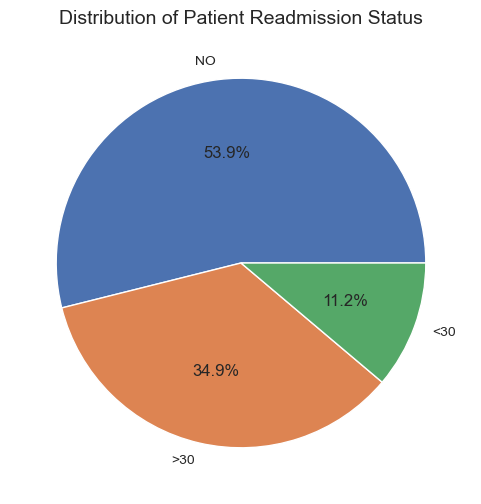

In [51]:
# Count values for readmission status
readmit_counts = df['readmitted'].value_counts()

# Plot simple pie chart
plt.figure(figsize=(6, 6))
plt.pie(readmit_counts, labels=readmit_counts.index, autopct='%1.1f%%')
plt.title("Distribution of Patient Readmission Status")
plt.show()

**Bar Plot (Patient Age Distribution)**

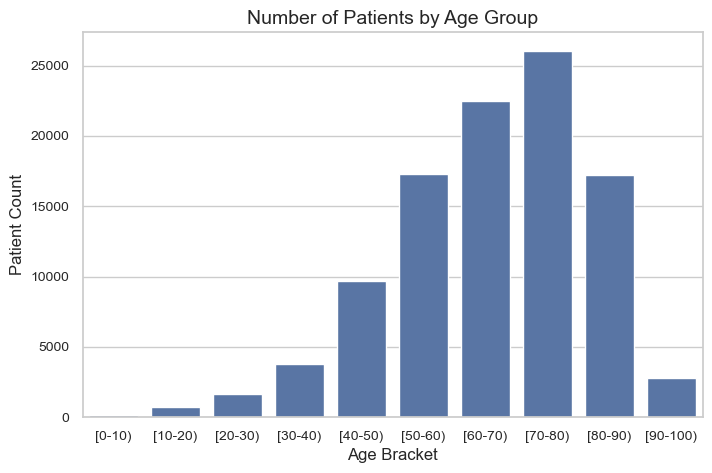

In [52]:
#  bar plot for age
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='age')
plt.title("Number of Patients by Age Group")
plt.xlabel("Age Bracket")
plt.ylabel("Patient Count")
plt.show()

**Histogram (Medication Counts)**

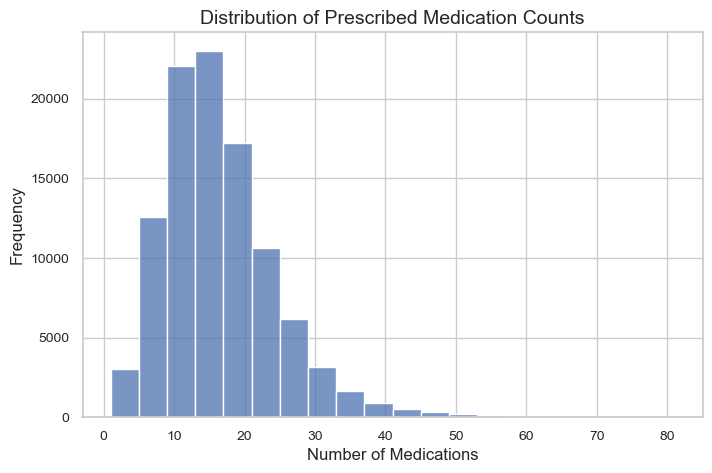

In [55]:
# histogram for medications
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='total_medications_prescribed', bins=20)
plt.title("Distribution of Prescribed Medication Counts")
plt.xlabel("Number of Medications")
plt.ylabel("Frequency")
plt.show()

**Box Plot (Hospital Stay Length vs Readmission)**

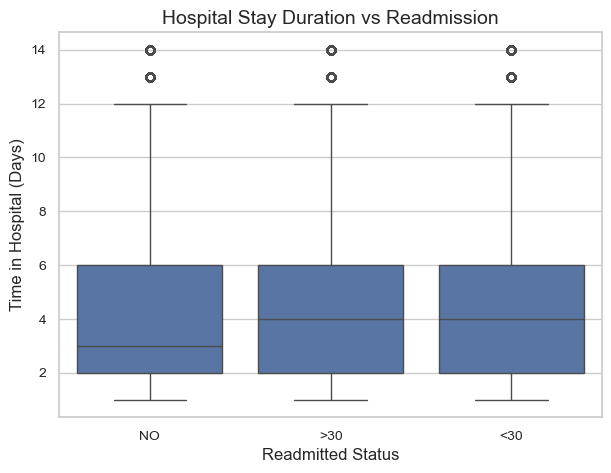

In [56]:
# box plot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='readmitted', y='time_in_hospital')
plt.title("Hospital Stay Duration vs Readmission")
plt.xlabel("Readmitted Status")
plt.ylabel("Time in Hospital (Days)")
plt.show()

**Scatter Plot (Lab Procedures vs Medications)**

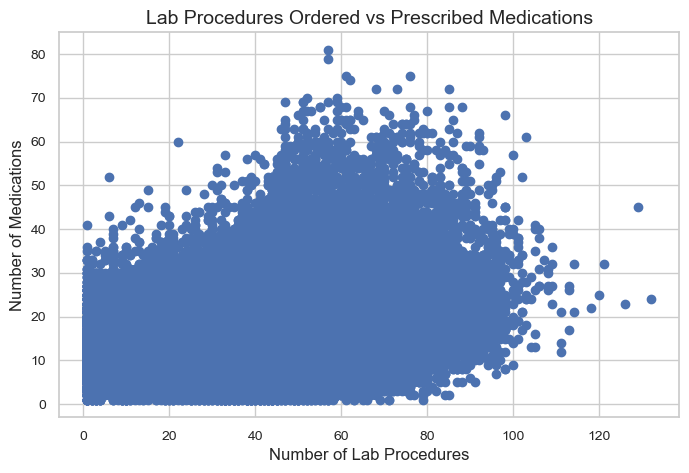

In [58]:
# scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['total_lab_procedures'], df['total_medications_prescribed'])
plt.title("Lab Procedures Ordered vs Prescribed Medications")
plt.xlabel("Number of Lab Procedures")
plt.ylabel("Number of Medications")
plt.show()

**Correlation Heatmap**

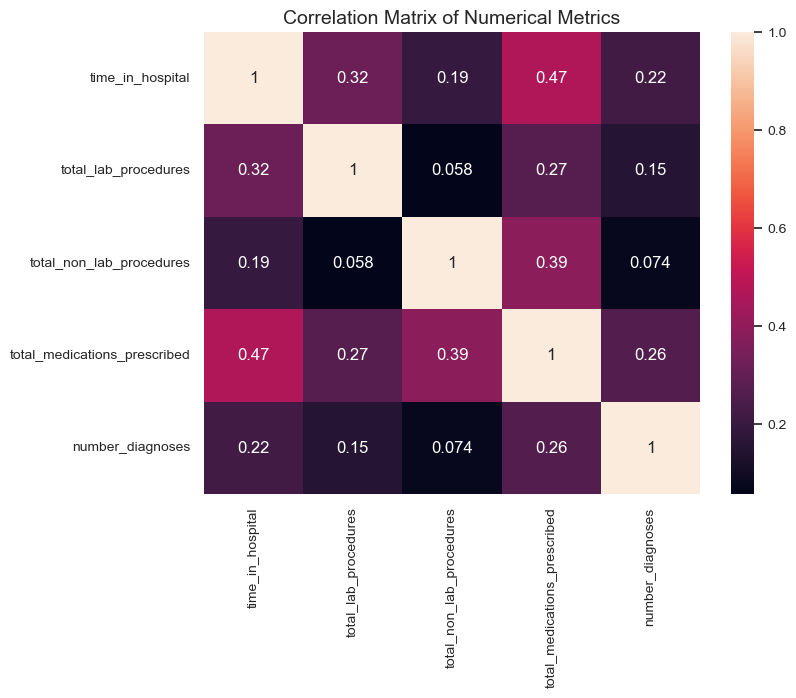

In [59]:
numeric_columns = [
    'time_in_hospital', 
    'total_lab_procedures', 
    'total_non_lab_procedures', 
    'total_medications_prescribed', 
    'number_diagnoses'
]

# Calculate 
corr = df[numeric_columns].corr()

# Draw plain heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix of Numerical Metrics")
plt.show()

# Insight Generation and Report Summary #

### Key Findings from Visualizations

1. **Patient Readmission Status (Pie Chart)**:
   - The pie chart shows how our target variable (`readmitted`) is distributed across the dataset, helping us see the balance between readmitted and non-readmitted patient encounters.

2. **Age Distribution (Bar Plot)**:
   - The bar plot indicates that a significant number of diabetic patients fall into the older age group intervals. This shows that the hospital sees more elderly diabetic patients compared to younger demographics.

3. **Medication Prescriptions (Histogram)**:
   - The histogram for `total_medications_prescribed` shows a normal-like distribution that is slightly skewed to the right. Most patients are prescribed a moderate number of unique medications during their stay.

4. **Hospital Stay vs. Readmission (Box Plot)**:
   - The box plot reveals that patients who were readmitted generally had a slightly longer `time_in_hospital` on average compared to those who were not readmitted.

5. **Lab and Medication Correlations (Scatter Plot & Heatmap)**:
   - The scatter plot and correlation heatmap reveal a positive relationship between `total_lab_procedures` and `total_medications_prescribed`. This shows that patients who receive more laboratory tests are often prescribed more medications during their stay.

---

### Short Conclusion and Next Steps
* **Findings**: Length of stay in the hospital, age brackets, and high prescription volumes appear to have visible relationships with patient outcomes and clinical complexity.
* **Recommendations**: The hospital can track patient stays and medication counts as indicators to flag cases that might require closer post-discharge care.
* **Next Steps**: Now that the data is thoroughly cleaned, analyzed, and visualized, it is ready for future reporting steps or modeling assignments.